<a href="https://colab.research.google.com/github/hrulevskaya/ML_tasks/blob/main/5task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
try:
    # Colab only
    %tensorflow_version 2.x
except Exception:
    pass
import tensorflow as tf

print(tf.__version__)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
2.20.0


In [ ]:
# # Подключаем наш гугл диск к блокноту
from google.colab import drive
drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [ ]:
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from skimage.transform import resize
from tqdm import tqdm

cats_files = glob("/content/gdrive/MyDrive/cats/*")
dogs_files = glob("/content/gdrive/MyDrive/dogs/*")

cats_images = [resize(plt.imread(file), (128, 128)) for file in tqdm(cats_files)]
dogs_images = [resize(plt.imread(file), (128, 128)) for file in tqdm(dogs_files)]

len(cats_images), len(dogs_images)

100%|██████████| 1012/1012 [03:22<00:00,  5.00it/s]


(1011, 1012)

In [ ]:
X = np.stack(cats_images + dogs_images)
y = np.float32([[0]] * len(cats_images) + [[1]] * len(dogs_files))

X.shape, y.shape

((2023, 128, 128, 3), (2023, 1))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [ ]:
model = Sequential()
for _ in range(5):
    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
#example
model.add(layers.Dense(1, activation='sigmoid'))

In [ ]:
batch_size = 32
epochs = 20

model.compile(
    loss=keras.losses.binary_crossentropy,
    optimizer="adamw",  # change
    metrics=["accuracy"],
)

history = model.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, y_test),
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.5099 - loss: 0.6934 - val_accuracy: 0.4926 - val_loss: 0.6881
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.5066 - loss: 0.6935 - val_accuracy: 0.5813 - val_loss: 0.6902
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.5412 - loss: 0.6860 - val_accuracy: 0.6207 - val_loss: 0.6641
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.5852 - loss: 0.6715 - val_accuracy: 0.5764 - val_loss: 0.6805
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6121 - loss: 0.6528 - val_accuracy: 0.6946 - val_loss: 0.6282
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.6549 - loss: 0.6218 - val_accuracy: 0.6798 - val_loss: 0.6365
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.6764 - loss: 0.5904 - val_accuracy: 0.7143 - val_loss: 0.6083
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.7044 - loss: 0.5656 - val_accuracy: 0.6601 - val_los

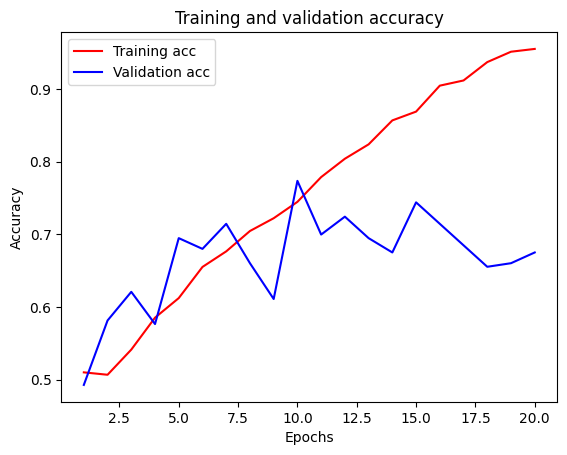

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "r", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step


In [ ]:
from sklearn.metrics import classification_report

labels_true = ["cat" if x == 0 else "dog" for x in y_test]
labels_pred = ["cat" if x < 0.5 else "dog" for x in y_pred]

print(classification_report(labels_true, labels_pred))

              precision    recall  f1-score   support

         cat       0.66      0.74      0.70       103
         dog       0.69      0.61      0.65       100

    accuracy                           0.67       203
   macro avg       0.68      0.67      0.67       203
weighted avg       0.68      0.67      0.67       203

